In [3]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
# Globalny motyw — raz, na początku notebooka
sns.set_theme(style='whitegrid', palette='muted')
# Dataset tips — restauracja, 244 rachunki (znany z W09)
tips = sns.load_dataset('tips')
print(f"Tips dataset: {tips.shape[0]} wierszy × {tips.shape[1]} kolumn")
print(f"Kolumny: {list(tips.columns)}")
tips.head(3)

Tips dataset: 244 wierszy × 7 kolumn
Kolumny: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


# Ćwiczenie 1: Statystyczne wykresy seaborn

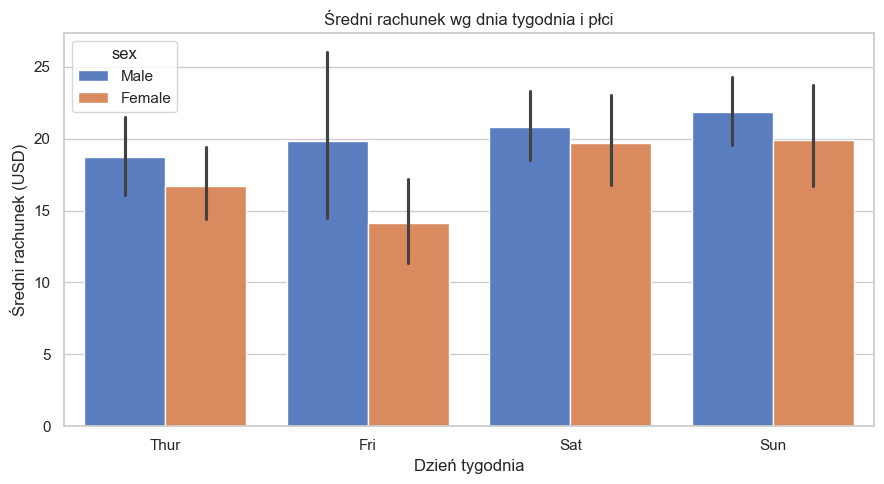

Zapisano: barplot_dzien_plec.png


In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
 data=tips,
 x='day',
 y='total_bill',
 hue='sex',
 ax=ax,
 palette='muted',
 errorbar=('ci', 95), # 95% CI = przedział ufności średniej
)
ax.set_title('Średni rachunek wg dnia tygodnia i płci')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Średni rachunek (USD)')
plt.tight_layout()
plt.savefig('barplot_dzien_plec.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: barplot_dzien_plec.png")

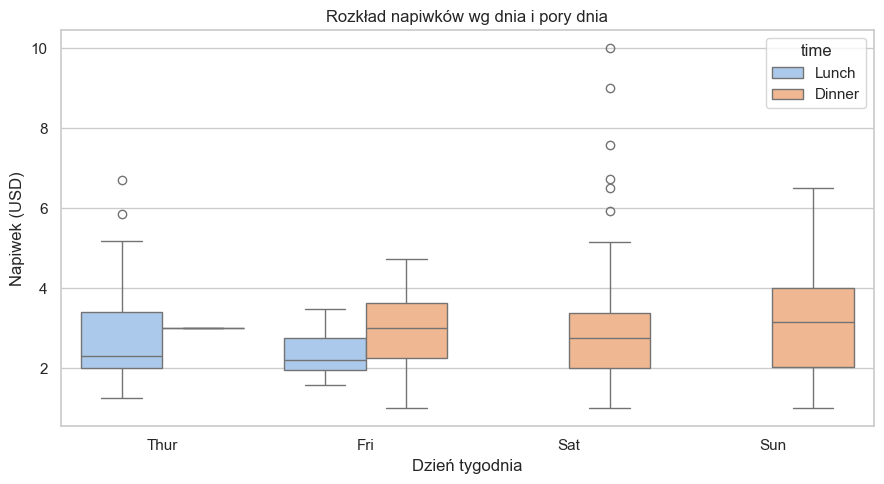

Zapisano: boxplot_napiwki.png


In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
        data = tips,
        x = 'day',
        y = 'tip',
        hue = 'time',
        ax = ax,
        palette='pastel'
        )
ax.set_title('Rozkład napiwków wg dnia i pory dnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Napiwek (USD)')
plt.tight_layout()
plt.savefig('boxplot_napiwki.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: boxplot_napiwki.png")

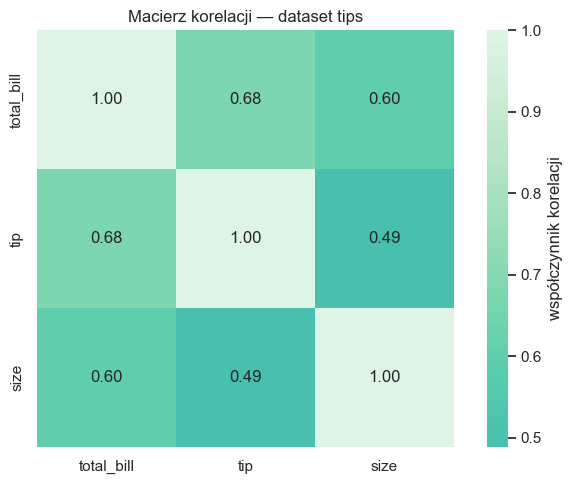

Zapisano: heatmap_korelacja.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
# Korelacja tylko zmiennych numerycznych
corr = tips.select_dtypes('number').corr()
sns.heatmap(
 corr,
 annot =  True,
 fmt = '.2f', 
 cmap = 'mako' ,
 center = 0, 
 ax = ax,
 square = True,
 cbar_kws = {'label': 'współczynnik korelacji'}
)
ax.set_title('Macierz korelacji — dataset tips')
plt.tight_layout()
plt.savefig('heatmap_korelacja.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: heatmap_korelacja.png")

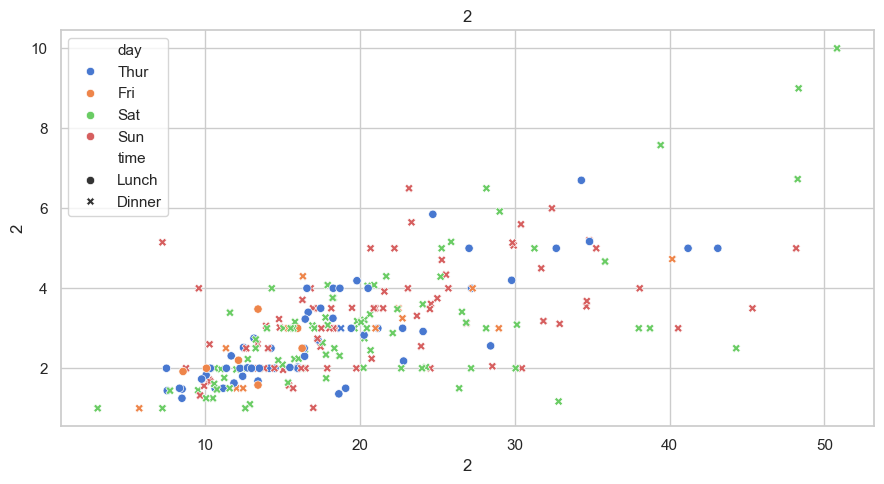

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
# Twój kod
sns.scatterplot(
data=tips,
x='total_bill',
y='tip', 
hue='day',
style='time',
ax=ax
)
ax.set_title(2)
ax.set_xlabel(2)
ax.set_ylabel(2)
plt.tight_layout()
plt.savefig('scatter_rachunek_napiwek.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()


# Ćwiczenie 2: Subplots, GridSpec, shared axes

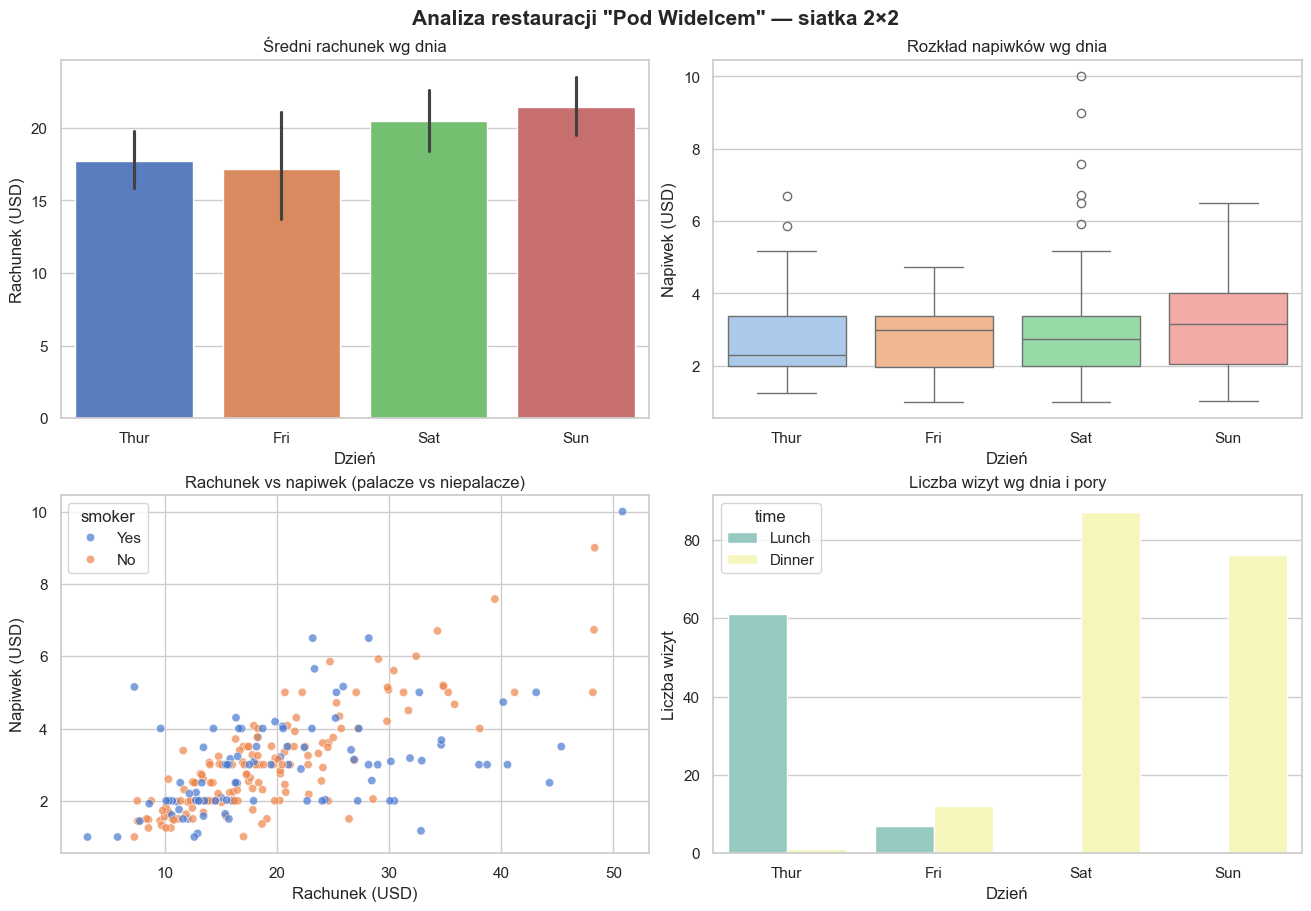

Zapisano: siatka_2x2.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

# Panel [0, 0] — barplot (gotowy wzór)
sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False, 
            ax=axes[0, 0], palette='muted', errorbar=('ci', 95))

axes[0, 0].set_title('Średni rachunek wg dnia')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Rachunek (USD)')

# Panel [0, 1] — boxplot (uzupełnij)
sns.boxplot(
    data=tips,
    x='day', 
    y='tip', 
    hue='day', 
    legend=False,
    ax=axes[0, 1],
    palette='pastel',
)
axes[0, 1].set_title('Rozkład napiwków wg dnia')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Napiwek (USD)')

# Panel [1, 0] — scatter (uzupełnij)
sns.scatterplot(
    data=tips,
    x='total_bill', 
    y='tip', 
    hue='smoker',
    alpha=0.7,
    ax=axes[1, 0],
)
axes[1, 0].set_title('Rachunek vs napiwek (palacze vs niepalacze)')
axes[1, 0].set_xlabel('Rachunek (USD)')
axes[1, 0].set_ylabel('Napiwek (USD)')

# Panel [1, 1] — countplot (uzupełnij)
sns.countplot(
    data=tips,
    x='day', 
    hue='time',
    ax=axes[1, 1],
    palette='Set3',
)
axes[1, 1].set_title('Liczba wizyt wg dnia i pory')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Liczba wizyt')

fig.suptitle('Analiza restauracji "Pod Widelcem" — siatka 2×2', 
             fontsize=15, fontweight='bold')

plt.savefig('siatka_2x2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

print("Zapisano: siatka_2x2.png")

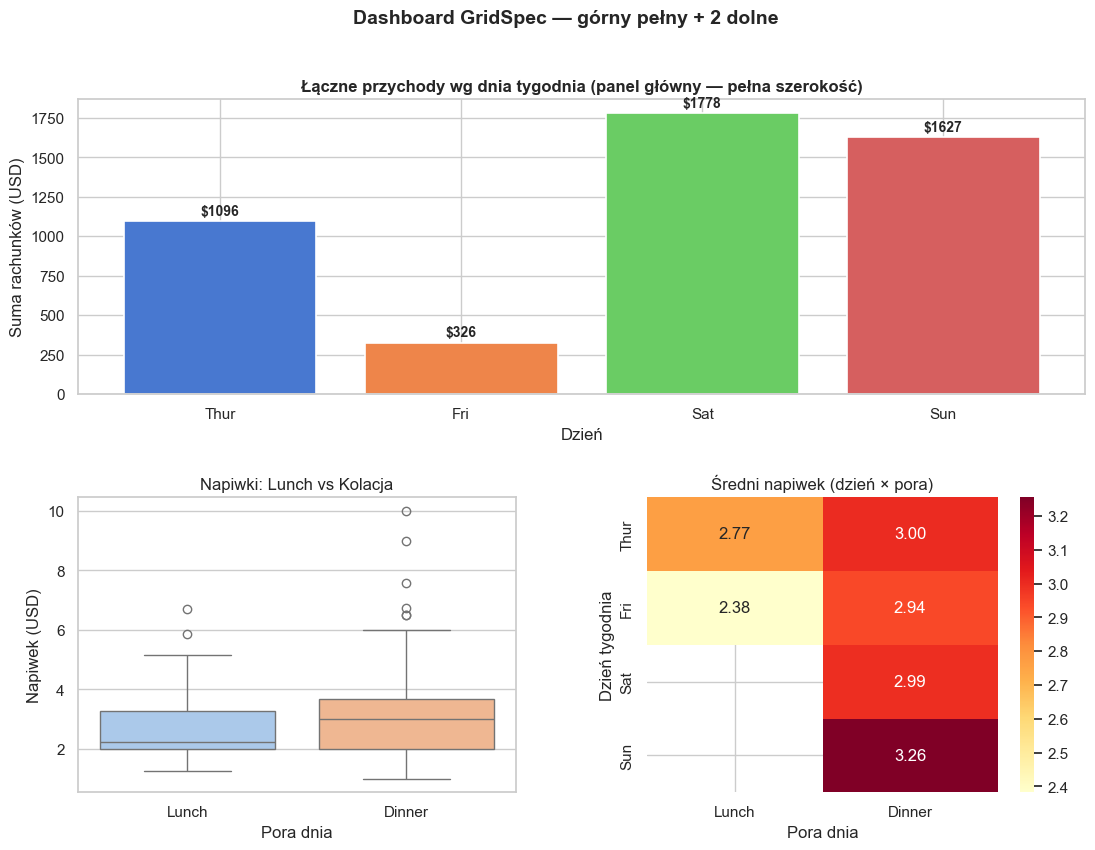

Zapisano: gridspec_dashboard.png


In [14]:
# Przygotowanie figury i GridSpec
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# --- PANEL GÓRNY (Pełna szerokość) ---
ax_top = fig.add_subplot(gs[0, :])
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
ax_top.bar(
    tips_sum['day'].astype(str),
    tips_sum['total_bill'],
    color=sns.color_palette('muted')[:4],
    edgecolor='white', linewidth=1.2,
)

# Dodaj wartości nad słupkami
for i, val in enumerate(tips_sum['total_bill']):
    ax_top.text(i, val + 20, f'${val:.0f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax_top.set_title('Łączne przychody wg dnia tygodnia (panel główny — pełna szerokość)', 
                 fontsize=12, fontweight='bold')
ax_top.set_xlabel('Dzień')
ax_top.set_ylabel('Suma rachunków (USD)')

# --- PANEL DOLNY LEWY (Boxplot) ---
ax_bl = fig.add_subplot(gs[1, 0])
sns.boxplot(
    data=tips,
    x='time',      # Uzupełnione
    y='tip',       # Uzupełnione
    hue='time', 
    legend=False,
    ax=ax_bl,
    palette='pastel',
)
ax_bl.set_title('Napiwki: Lunch vs Kolacja')
ax_bl.set_xlabel('Pora dnia')
ax_bl.set_ylabel('Napiwek (USD)')

# --- PANEL DOLNY PRAWY (Heatmap Pivot) ---
ax_br = fig.add_subplot(gs[1, 1])

# Tworzenie tabeli przestawnej (Pivot Table)
pivot = tips.pivot_table(
    values='tip', 
    index='day', 
    columns='time', 
    aggfunc='mean', 
    observed=True
)

# Wizualizacja Heatmapy
sns.heatmap(
    data=pivot, 
    annot=True, 
    fmt='.2f', 
    cmap='YlOrRd', 
    ax=ax_br
)

ax_br.set_title('Średni napiwek (dzień × pora)')
ax_br.set_xlabel('Pora dnia')
ax_br.set_ylabel('Dzień tygodnia')

# Nagłówek i zapis
fig.suptitle('Dashboard GridSpec — górny pełny + 2 dolne', 
             fontsize=14, fontweight='bold')

plt.savefig('gridspec_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

print("Zapisano: gridspec_dashboard.png")

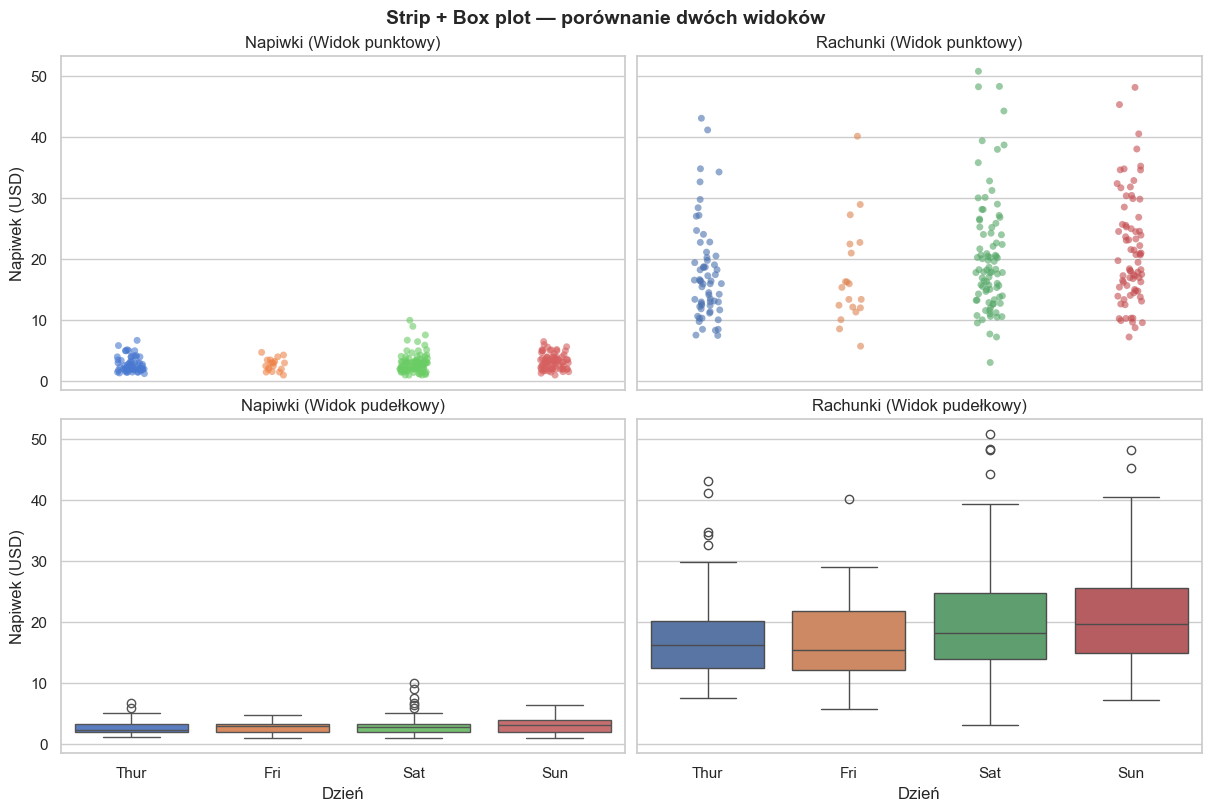

Zapisano: shared_axes.png


In [16]:
# Przygotowanie siatki z dzielonymi osiami
fig, axes = plt.subplots(2, 2, figsize=(12, 8), 
                         sharex='col', sharey='row', 
                         constrained_layout=True)

# --- LEWA KOLUMNA: Napiwki (tip) ---

# [0, 0] Stripplot napiwki
sns.stripplot(data=tips, x='day', y='tip', hue='day', 
              ax=axes[0, 0], palette='muted', alpha=0.6, legend=False)
axes[0, 0].set_title('Napiwki (Widok punktowy)')
axes[0, 0].set_ylabel('Napiwek (USD)')

# [1, 0] Boxplot napiwki
sns.boxplot(data=tips, x='day', y='tip', hue='day', 
            ax=axes[1, 0], palette='muted', legend=False)
axes[1, 0].set_title('Napiwki (Widok pudełkowy)')
axes[1, 0].set_ylabel('Napiwek (USD)')
axes[1, 0].set_xlabel('Dzień')


# --- PRAWA KOLUMNA: Rachunki (total_bill) ---

# [0, 1] Stripplot rachunki
sns.stripplot(data=tips, x='day', y='total_bill', hue='day', 
              ax=axes[0, 1], palette='deep', alpha=0.6, legend=False)
axes[0, 1].set_title('Rachunki (Widok punktowy)')
axes[0, 1].set_ylabel('Rachunek (USD)')

# [1, 1] Boxplot rachunki
sns.boxplot(data=tips, x='day', y='total_bill', hue='day', 
            ax=axes[1, 1], palette='deep', legend=False)
axes[1, 1].set_title('Rachunki (Widok pudełkowy)')
axes[1, 1].set_ylabel('Rachunek (USD)')
axes[1, 1].set_xlabel('Dzień')

# Tytuł główny i zapis
fig.suptitle('Strip + Box plot — porównanie dwóch widoków', 
             fontsize=14, fontweight='bold')

plt.savefig('shared_axes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

print("Zapisano: shared_axes.png")

# Ćwiczenie 3: Pełny dashboard analityczny

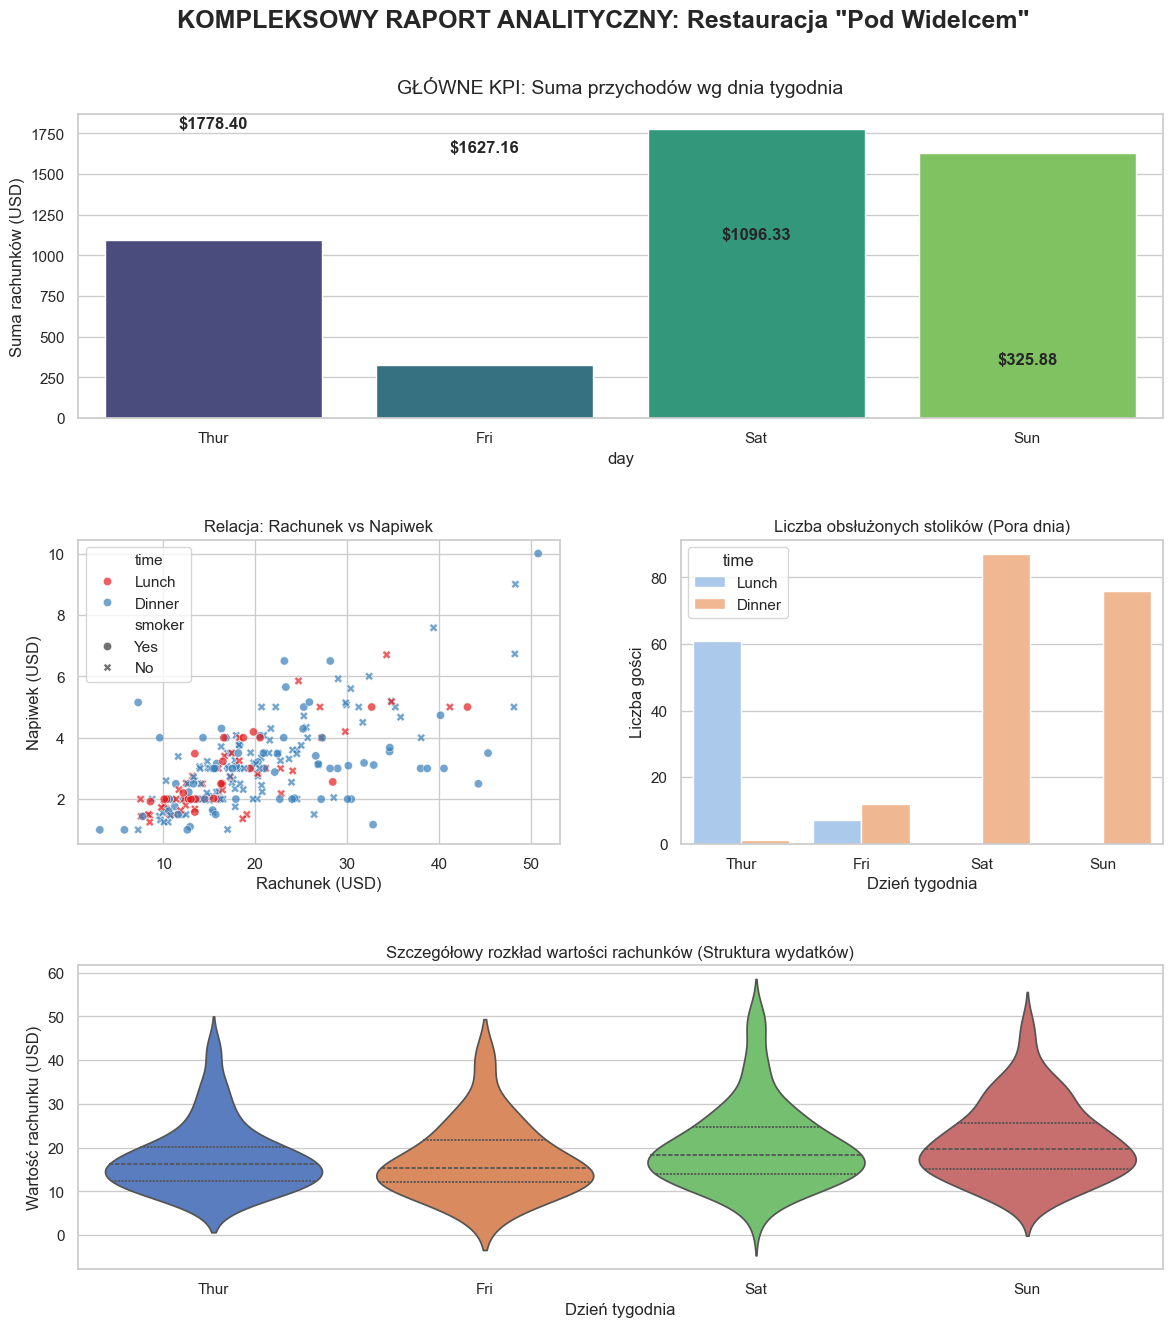

Dashboard został wygenerowany i zapisany jako 'dashboard_final.png'


In [18]:
# Ustawienie stylu
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(14, 15))

# Definicja siatki: 3 wiersze, 2 kolumny
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.25)

# --- 1. PANEL GŁÓWNY (KPI): Suma przychodów (gs[0, :]) ---
ax_main = fig.add_subplot(gs[0, :])
# Agregacja danych do KPI
revenue_day = tips.groupby('day', observed=True)['total_bill'].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=revenue_day, x='day', y='total_bill', hue='day', 
            palette='viridis', ax=ax_main, legend=False)

# Dodanie etykiet wartości na słupkach
for i, v in enumerate(revenue_day['total_bill']):
    ax_main.text(i, v + 5, f'${v:.2f}', ha='center', fontweight='bold')

ax_main.set_title('GŁÓWNE KPI: Suma przychodów wg dnia tygodnia', fontsize=14, pad=15)
ax_main.set_ylabel('Suma rachunków (USD)')


# --- 2. PANEL POMOCNICZY: Korelacja (gs[1, 0]) ---
ax_scat = fig.add_subplot(gs[1, 0])
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', 
                style='smoker', palette='Set1', alpha=0.7, ax=ax_scat)
ax_scat.set_title('Relacja: Rachunek vs Napiwek')
ax_scat.set_xlabel('Rachunek (USD)')
ax_scat.set_ylabel('Napiwek (USD)')


# --- 3. PANEL POMOCNICZY: Ruch w czasie (gs[1, 1]) ---
ax_count = fig.add_subplot(gs[1, 1])
sns.countplot(data=tips, x='day', hue='time', palette='pastel', ax=ax_count)
ax_count.set_title('Liczba obsłużonych stolików (Pora dnia)')
ax_count.set_xlabel('Dzień tygodnia')
ax_count.set_ylabel('Liczba gości')


# --- 4. PANEL SUMARYCZNY: Rozkład (gs[2, :]) ---
ax_viol = fig.add_subplot(gs[2, :])
sns.violinplot(data=tips, x='day', y='total_bill', hue='day', 
               palette='muted', inner='quartile', ax=ax_viol, legend=False)
ax_viol.set_title('Szczegółowy rozkład wartości rachunków (Struktura wydatków)', fontsize=12)
ax_viol.set_xlabel('Dzień tygodnia')
ax_viol.set_ylabel('Wartość rachunku (USD)')


# Wykończenie dashboardu
fig.suptitle('KOMPLEKSOWY RAPORT ANALITYCZNY: Restauracja "Pod Widelcem"', 
             fontsize=18, fontweight='bold', y=0.95)

# Zapis i wyświetlenie
plt.savefig('dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard został wygenerowany i zapisany jako 'dashboard_final.png'")

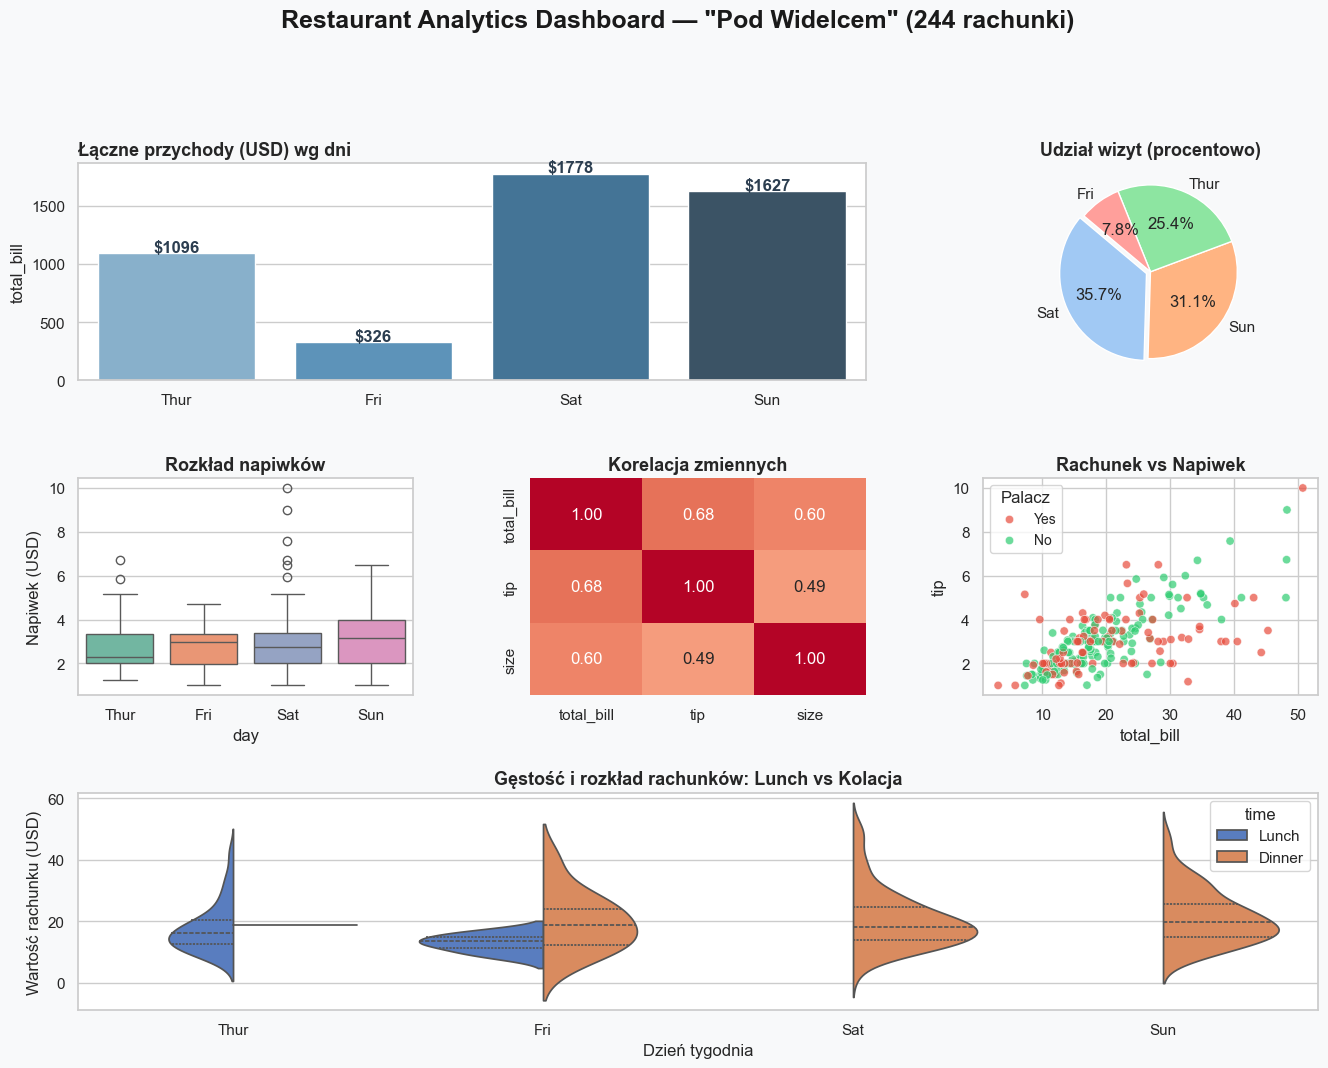

Zapisano: dashboard_pod_widelcem.png


In [19]:
# Zakładamy, że 'tips' jest już wczytany (sns.load_dataset('tips'))
sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#f8f9fa')  # tło figury — jasnoszare
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# === PANEL 1 (KPI główny): łączne przychody per dzień (gs[0, :2]) ===
ax1 = fig.add_subplot(gs[0, :2])
daily_revenue = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(data=daily_revenue, x='day', y='total_bill', hue='day', palette='Blues_d', ax=ax1, legend=False)
for i, val in enumerate(daily_revenue['total_bill']):
    ax1.text(i, val + 10, f'${val:.0f}', ha='center', fontweight='bold', color='#2c3e50')
ax1.set_title('Łączne przychody (USD) wg dni', loc='left', fontsize=13, fontweight='bold')
ax1.set_xlabel('')

# === PANEL 2: udział wizyt per dzień (gs[0, 2]) ===
ax2 = fig.add_subplot(gs[0, 2])
day_counts = tips['day'].value_counts()
ax2.pie(day_counts, labels=day_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=140, explode=[0.05, 0, 0, 0])
ax2.set_title('Udział wizyt (procentowo)', fontsize=13, fontweight='bold')

# === PANEL 3: rozkład napiwków (gs[1, 0]) ===
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=tips, x='day', y='tip', hue='day', palette='Set2', ax=ax3, legend=False)
ax3.set_title('Rozkład napiwków', fontsize=13, fontweight='bold')
ax3.set_ylabel('Napiwek (USD)')

# === PANEL 4: heatmap korelacji (gs[1, 1]) ===
ax4 = fig.add_subplot(gs[1, 1])
# Wybieramy tylko kolumny numeryczne do korelacji
corr = tips.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax4, cbar=False)
ax4.set_title('Korelacja zmiennych', fontsize=13, fontweight='bold')

# === PANEL 5: scatter (gs[1, 2]) ===
ax5 = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker', 
                palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, alpha=0.7, ax=ax5)
ax5.set_title('Rachunek vs Napiwek', fontsize=13, fontweight='bold')
ax5.legend(title='Palacz', loc='upper left', fontsize='small')

# === PANEL 6 (sumaryczny): rozkład rachunków (gs[2, :]) ===
ax6 = fig.add_subplot(gs[2, :])
sns.violinplot(data=tips, x='day', y='total_bill', hue='time', split=True, 
               palette='muted', inner='quartile', ax=ax6)
ax6.set_title('Gęstość i rozkład rachunków: Lunch vs Kolacja', fontsize=13, fontweight='bold')
ax6.set_ylabel('Wartość rachunku (USD)')
ax6.set_xlabel('Dzień tygodnia')

# Globalne wykończenie
fig.suptitle('Restaurant Analytics Dashboard — "Pod Widelcem" (244 rachunki)', 
             fontsize=18, fontweight='bold', y=1.02, color='#1a1a1a')

plt.savefig('dashboard_pod_widelcem.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

print("Zapisano: dashboard_pod_widelcem.png")

# Ćwiczenie 4: Style, eksport, adnotacja, commit

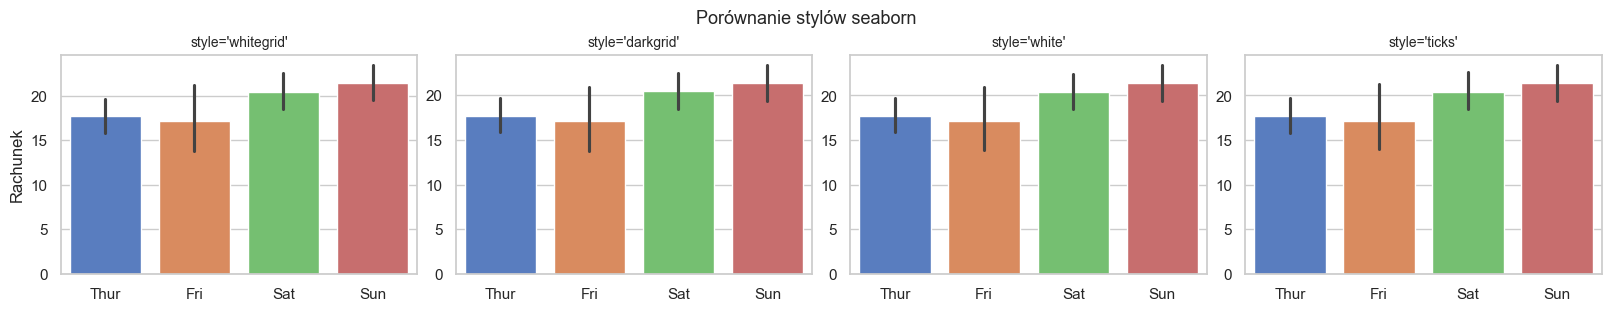

In [25]:
styles = ['whitegrid', 'darkgrid', 'white', 'ticks']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), constrained_layout=True)
for ax, style in zip(axes, styles):
 with sns.axes_style(style): 
    sns.barplot(
     data = tips,
     x='day', 
     y='total_bill', 
     hue='day', 
     legend=False,
     ax=ax, 
     palette='muted')
 ax.set_title(f"style='{style}'", fontsize=10)
 ax.set_xlabel('')
 ax.set_ylabel('Rachunek' if ax is axes[0] else '')
fig.suptitle('Porównanie stylów seaborn', fontsize=13)
plt.savefig('porownanie_stylow.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()


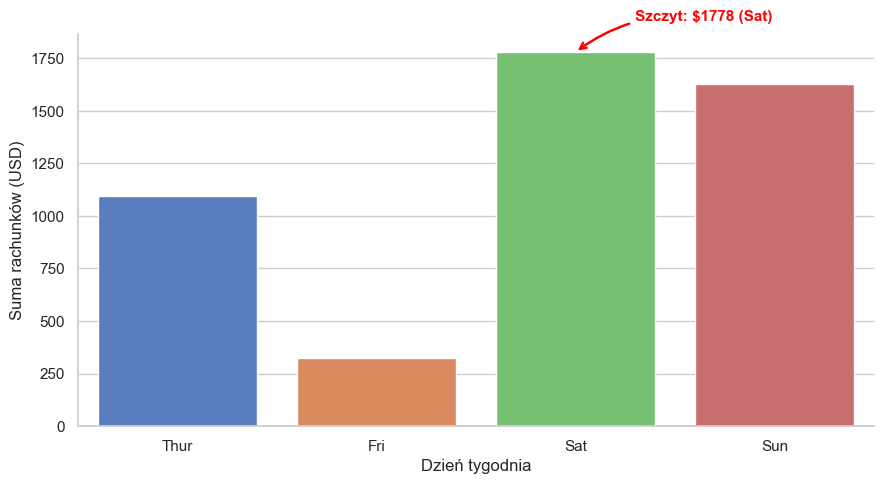

Zapisano: szczyt_przychodow.png


In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()

sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False,
            ax=ax, palette='muted')

# Znajdź szczyt
max_idx = tips_sum['total_bill'].idxmax()
max_day = tips_sum.loc[max_idx, 'day']
max_val = tips_sum.loc[max_idx, 'total_bill']

# Adnotacja ze strzałką
ax.annotate(
    f'Szczyt: ${max_val:.0f} ({max_day})',
    xy=(max_idx, max_val),           # Punkt, na który wskazuje strzałka
    xytext=(max_idx + 0.3, max_val + 150),  # Gdzie znajduje się tekst (lekki offset)
    arrowprops=dict(
        arrowstyle='->', 
        color='red', 
        lw=1.8,
        connectionstyle="arc3,rad=.2" # Dodaje lekkie zakrzywienie strzałki dla lepszego wyglądu
    ),
    fontsize=11, 
    color='red', 
    fontweight='bold',
)

ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Suma rachunków (USD)')

# Usuwa górną i prawą krawędź osi (styl minimalistyczny)
sns.despine() 

plt.tight_layout()
plt.savefig('szczyt_przychodow.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

print("Zapisano: szczyt_przychodow.png")